# Zoonotic Foodborne Diseases in EU/EEA (2022–2024) — ECDC

This script produces:
- A summary CSV of total EU/EEA cases
- A bar plot

**IMPORTANT:**  
ECDC's Surveillance Atlas separates:

- **Indicator** = category of measure  
- **Subpopulation** = case definition  

When downloading CONFIRMED CASE COUNTS:
- Indicator = "Reported cases"  
- Subpopulation = "Confirmed cases"


=====================================================================
Imports and plotting style
=====================================================================

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

In [4]:
# ---- One Earth visual style (kept as in your version) ----
ONE_EARTH_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 300,
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.titlepad": 10,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.30,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "lines.linewidth": 2.2,
}
mpl.rcParams.update(ONE_EARTH_RC)

In [5]:
def tight_layout(fig, top=0.92, bottom=0.12, left=0.10, right=0.98, wspace=0.25, hspace=0.30):
    """Compact layout helper for consistent margins."""
    fig.subplots_adjust(top=top, bottom=bottom, left=left, right=right, wspace=wspace, hspace=hspace)

=====================================================================
User configuration
=====================================================================

In [6]:
YEARS = [2022, 2023, 2024]
DISEASES = ["Campylobacteriosis", "Salmonellosis", "Listeriosis"]

In [7]:
DATA_DIR = Path("./data")
DISEASE_FILES = {
    "Campylobacteriosis": DATA_DIR / "ECDC_surveillance_data_Campylobacteriosis.csv",
    "Salmonellosis":      DATA_DIR / "ECDC_surveillance_data_Salmonellosis.csv",
    "Listeriosis":        DATA_DIR / "ECDC_surveillance_data_Listeriosis.csv",
}

In [8]:
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
OUT_CSV = OUTPUT_DIR / "ECDC_totals_2022_2024_by_disease.csv"
OUT_PNG = OUTPUT_DIR / "ECDC_totals_2022_2024_by_disease.png"
OUT_PDF = OUTPUT_DIR / "ECDC_totals_2022_2024_by_disease.pdf"

=====================================================================
Helpers for loading and validating the data
=====================================================================

In [10]:
def clean_num(series: pd.Series) -> pd.Series:
    """Convert messy numeric columns into clean numeric values.

    Handles:
      - commas (“1,234” → 1234)
      - spaces (“1 234” → 1234)
      - mixed string + numeric data
    """
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False),
        errors="coerce"
    )

In [11]:
def load_disease_csv(path: Path) -> pd.DataFrame:
    """Load ECDC CSV exactly as downloaded, ensure required columns exist."""
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")

    df = pd.read_csv(path)

    required = ["Time", "RegionCode", "Indicator", "Unit"]
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' missing in: {path.name}")

    return df

In [12]:
def check_indicator(df: pd.DataFrame, path: Path) -> None:
    """
    Validate the Indicator column.

    Correct interpretation per ECDC documentation:
        - When downloading CONFIRMED CASE COUNTS, Indicator == "Reported cases".
        - Subpopulation determines that these are confirmed cases.
    
    Therefore:
        - We warn only if the file does NOT contain "Reported cases".
        - We do NOT expect "Confirmed cases" in the Indicator column.
    """
    indicators = set(df["Indicator"].dropna().astype(str).str.strip().unique())

    if "Reported cases" not in indicators:
        print(
            f"[WARNING] {path.name}: Indicator does not contain 'Reported cases'. "
            f"Found: {sorted(indicators)}. "
            "Make sure the ECDC portal was filtered to Subpopulation = Confirmed cases."
        )
    else:
        print(f"[OK] {path.name}: Indicator includes 'Reported cases' (correct for confirmed case counts).")

=====================================================================
Core aggregation logic
=====================================================================

In [13]:
def total_cases_for_year(df: pd.DataFrame, year: int) -> int:
    """Compute total confirmed cases across EU/EEA countries for a given year.

    Steps:
    -------
    1. Keep only rows for this year.
    2. Keep only RegionCode length = 2 (EU/EEA country codes in ECDC exports).
    3. Prefer Indicator == "Reported cases".
       (ECDC uses this label for confirmed case counts.)
    4. Convert rate data ("N/100000") into counts when necessary.
    """
    df = df.copy()
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

    # Filter by year + country level codes
    sub = df[(df["Time"] == year) & (df["RegionCode"].astype(str).str.len() == 2)].copy()
    if sub.empty:
        return 0

    # Prefer "Reported cases" if multiple indicators exist
    inds = sub["Indicator"].astype(str).str.strip()
    if "Reported cases" in inds.unique():
        sub = sub[inds == "Reported cases"].copy()

    # Clean numeric fields
    for c in ["NumValue", "Population", "Denominator"]:
        if c in sub.columns:
            sub[c] = clean_num(sub[c])

    # Convert counts or rates to final case numbers
    if "Unit" in sub.columns:
        unit = sub["Unit"].astype(str).str.upper().str.strip()
        is_count = (unit == "N")
        is_rate = (unit == "N/100000")

        sub["__cases__"] = 0.0

        # Direct counts
        sub.loc[is_count, "__cases__"] = sub.loc[is_count, "NumValue"]

        # Convert rates using population
        pop_col = "Population" if "Population" in sub.columns else (
            "Denominator" if "Denominator" in sub.columns else None
        )
        if is_rate.any() and pop_col is not None:
            sub.loc[is_rate, "__cases__"] = (
                sub.loc[is_rate, "NumValue"] * sub.loc[is_rate, pop_col] / 100000.0
            )
    else:
        # If Unit is missing, assume NumValue are raw counts
        sub["__cases__"] = sub["NumValue"]

    return int(round(sub["__cases__"].sum(skipna=True)))

=====================================================================
Load, validate, aggregate
=====================================================================

In [14]:
rows = []
for disease, path in DISEASE_FILES.items():
    df = load_disease_csv(path)
    check_indicator(df, path)

    for y in YEARS:
        total = total_cases_for_year(df, y)
        rows.append({"Year": y, "Disease": disease, "Total_cases": total})

[OK] ECDC_surveillance_data_Campylobacteriosis.csv: Indicator includes 'Reported cases' (correct for confirmed case counts).
[OK] ECDC_surveillance_data_Salmonellosis.csv: Indicator includes 'Reported cases' (correct for confirmed case counts).
[OK] ECDC_surveillance_data_Listeriosis.csv: Indicator includes 'Reported cases' (correct for confirmed case counts).


In [15]:
summary = pd.DataFrame(rows).sort_values(["Year", "Disease"]).reset_index(drop=True)

In [31]:
summary.to_csv(OUT_CSV, index=False)
print("Saved summary CSV:", OUT_CSV.resolve())
summary.head(9)

,Year,Disease,Total_cases
0,2022,Campylobacteriosis,142359
1,2022,Listeriosis,2812
2,2022,Salmonellosis,66237
3,2023,Campylobacteriosis,150859
4,2023,Listeriosis,2994
5,2023,Salmonellosis,78307
6,2024,Campylobacteriosis,171680
7,2024,Listeriosis,3077
8,2024,Salmonellosis,80978


=====================================================================
Plot 
=====================================================================

In [17]:
pivot = summary.pivot(index="Year", columns="Disease", values="Total_cases") \
               .reindex(index=YEARS, columns=DISEASES)

In [27]:
print(summary)


   Year             Disease  Total_cases
0  2022  Campylobacteriosis       142359
1  2022         Listeriosis         2812
2  2022       Salmonellosis        66237
3  2023  Campylobacteriosis       150859
4  2023         Listeriosis         2994
5  2023       Salmonellosis        78307
6  2024  Campylobacteriosis       171680
7  2024         Listeriosis         3077
8  2024       Salmonellosis        80978


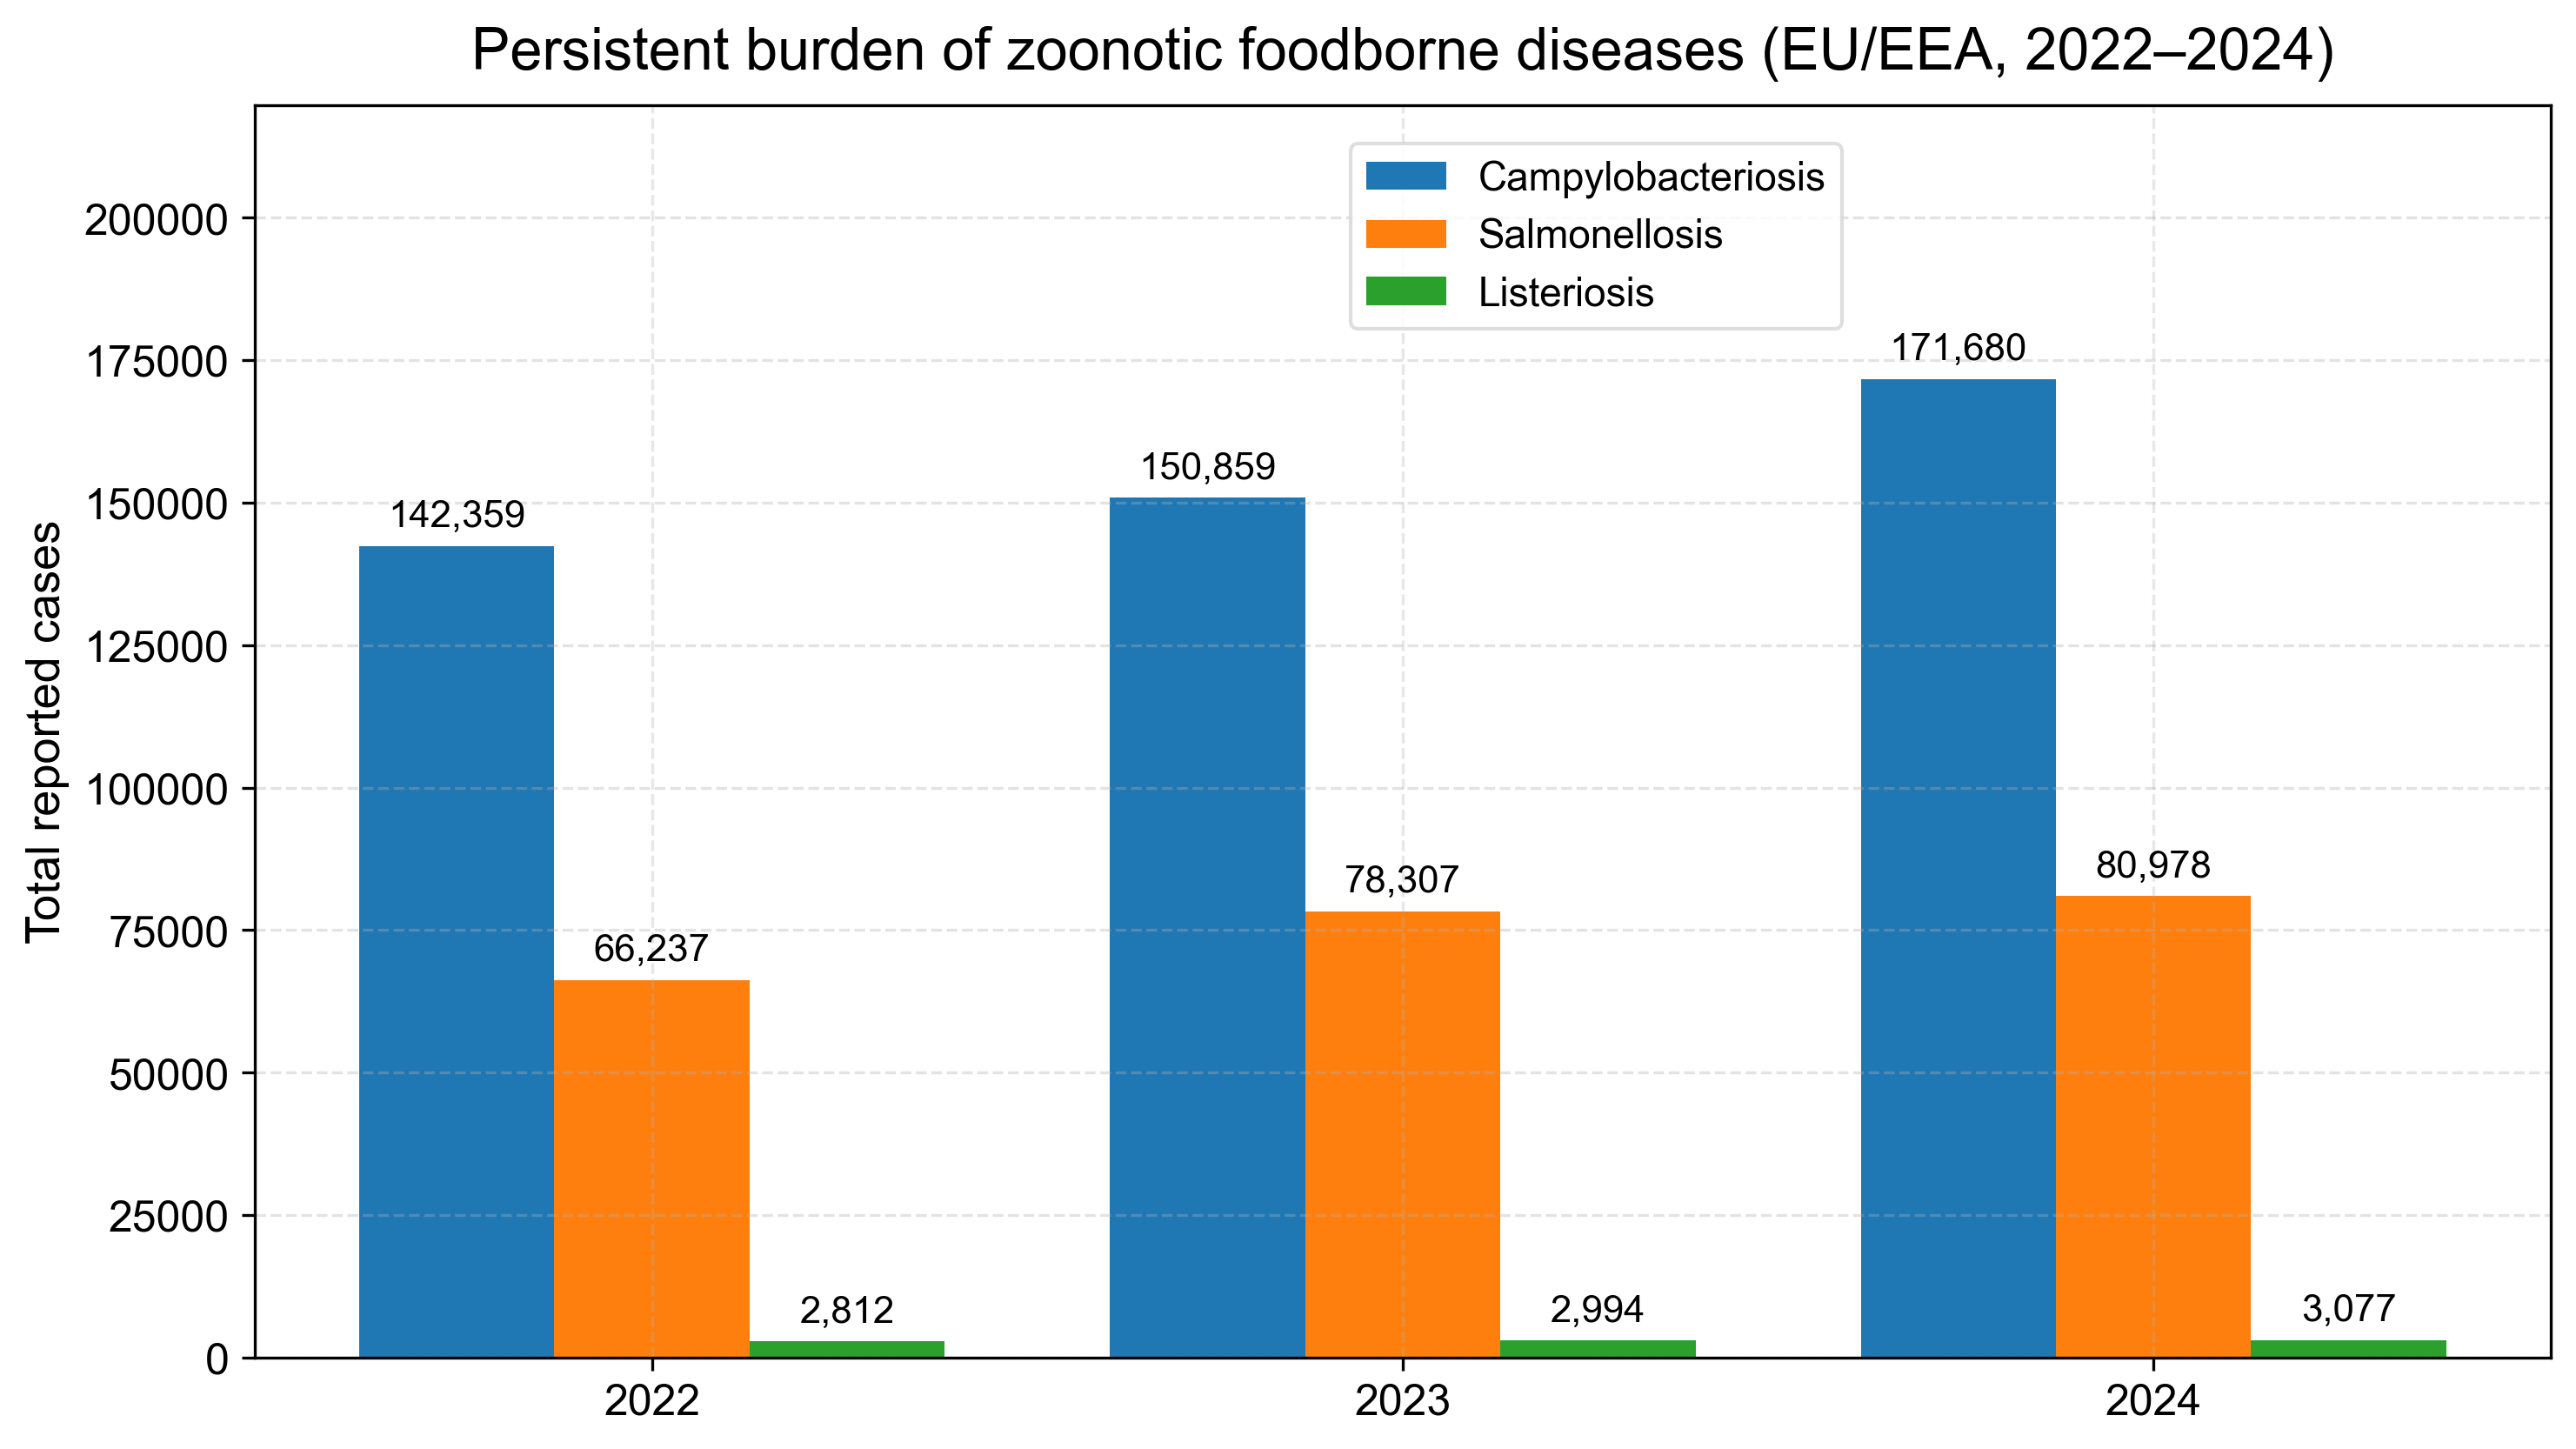

Saved figure: /Users/ritukajaiswal/Desktop/Climate Change Book/Animal Farming Paper/plots/Final Plots for livestock emissions/zoonisis and animal farming/Zoonotic diseases 2022-2024/2022-2024 Zoonotic diseases/output/ECDC_totals_2022_2024_by_disease.png
Saved figure: /Users/ritukajaiswal/Desktop/Climate Change Book/Animal Farming Paper/plots/Final Plots for livestock emissions/zoonisis and animal farming/Zoonotic diseases 2022-2024/2022-2024 Zoonotic diseases/output/ECDC_totals_2022_2024_by_disease.pdf


In [29]:
fig, ax = plt.subplots()

x = np.arange(len(YEARS))
width = 0.26
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

bars = []
for i, (d, c) in enumerate(zip(DISEASES, colors)):
    vals = pivot[d].fillna(0).astype(int).values
    bars.append(ax.bar(x + (i - 1)*width, vals, width=width, label=d, color=c))

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in YEARS])
ax.set_ylabel("Total reported cases")
ax.set_title("Persistent burden of zoonotic foodborne diseases (EU/EEA, 2022–2024)")

# Put numbers above bars
ymax = float(pivot.max().max()) if not np.isnan(pivot.max().max()) else 0
for grp in bars:
    for b in grp:
        v = int(b.get_height())
        if v > 0:
            ax.text(
                b.get_x() + b.get_width()/2,
                v + 0.012 * max(ymax, 1.0),
                f"{v:,}",
                ha="center", va="bottom", fontsize=10.5
            )

# Legend
ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.70, 0.985),
    frameon=True, facecolor="white", framealpha=0.85, edgecolor="0.85"
)

# Y-axis limits & grid
ax.set_ylim(0, max(ymax * 1.28, 1.0))
ax.grid(axis="y", linestyle="--", alpha=0.35)

tight_layout(fig)

# Display final plot
plt.show()

# Save output files
fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")

print("Saved figure:", OUT_PNG.resolve())
print("Saved figure:", OUT_PDF.resolve())
